# Module Import

In [93]:
# !pip install tensorflow -q

In [94]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from sklearn.utils import resample

# Load Datasets

In [95]:
train_dt = pd.read_csv("train.csv", names = ["Class Index", "Title", "Description"])
test_dt = pd.read_csv("test.csv", names = ["Class Index", "Title", "Description"])

class_names = {1:"World", 2:"Sports", 3:"Business", 4:"Sci/Tech"}
train_dt["class"] = train_dt["Class Index"].map(class_names)
test_dt["class"] = test_dt["Class Index"].map(class_names)


# Drop the first row which contains headers
train_dt = train_dt.iloc[1:].copy()
test_dt = test_dt.iloc[1:].copy()

# Convert 'Class Index' to integer
train_dt['Class Index'] = train_dt['Class Index'].astype(int)
test_dt['Class Index'] = test_dt['Class Index'].astype(int)

# Remap the class names after dropping the header row
train_dt["class"] = train_dt["Class Index"].map(class_names)
test_dt["class"] = test_dt["Class Index"].map(class_names)


print(f"Training dataset: {len(train_dt)}")
print(f"Testing dataset: {len(test_dt)}")

Training dataset: 120000
Testing dataset: 7600


# **EDA**


In [96]:
#dataset size
print(f"Training Dataset Size: {train_dt.shape}")
print(f"Testing Dataset Size: {test_dt.shape}")

#number of classes
if "class" in train_dt.columns:
  num_classes = len(train_dt["class"].dropna().unique())
  print(f"Number of Classes: {num_classes}")
else:
  print("No 'class' column in the dataset.")

# presence of missing values
missing_values = train_dt.isnull().sum()
print("Missing Values:", missing_values)

#class distribution
class_distribution = train_dt["class"].dropna().value_counts()
print(f"Class Distribution: {class_distribution}")

Training Dataset Size: (120000, 4)
Testing Dataset Size: (7600, 4)
Number of Classes: 4
Missing Values: Class Index    0
Title          0
Description    0
class          0
dtype: int64
Class Distribution: class
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


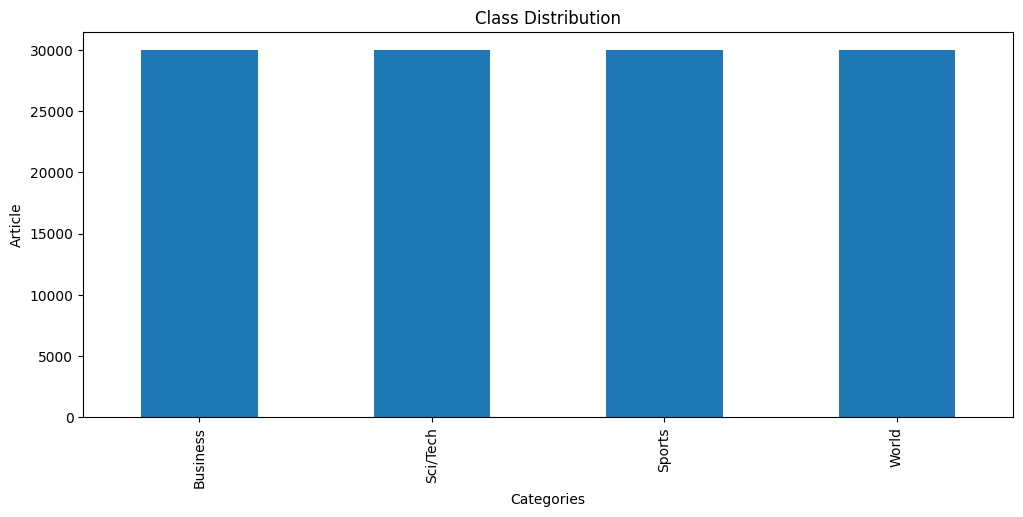

class
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [97]:
#display class distribution using count plot/bar chart
import matplotlib.pyplot as plt
if "class" in train_dt.columns:
  class_distribution = train_dt["class"].dropna().value_counts()
  plt.figure(figsize=(12, 5))
  class_distribution.plot(kind="bar")
  plt.title("Class Distribution")
  plt.xlabel("Categories")
  plt.ylabel("Article")
  plt.show()
  print(class_distribution)
else:
  print("No 'class' column in the dataset.")

In [98]:
#analyze text statistics such as average sentence length, word frequency, etc
train_dt["text_length"] = train_dt["Description"].str.len()
train_dt["word_count"] = train_dt["Description"].str.split().str.len()
train_dt["sentence_count"] = train_dt["Description"].str.count("\.")

print(f"Average Sentence Length: {train_dt['text_length'].mean():.4f}")
print(f"Average Word Count: {train_dt['word_count'].mean()}:.4f")
print(f"Average Sentence Count: {train_dt['sentence_count'].mean():.4f}")

print(f"Maximum Sentence Length: {train_dt['text_length'].max()}")
print(f"Maximum Word Count: {train_dt['word_count'].max()}")
print(f"Maximum Sentence Count: {train_dt['sentence_count'].max()}")

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1152152318.py:4: SyntaxWarning: invalid escape sequence '\.'
  train_dt["sentence_count"] = train_dt["Description"].str.count("\.")


Average Sentence Length: 193.3885
Average Word Count: 31.060508333333335:.4f
Average Sentence Count: 1.7215
Maximum Sentence Length: 985
Maximum Word Count: 173
Maximum Sentence Count: 28


# **Data Preprocessing **

In [99]:
#tokenize
num_words = 10000
tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_dt["Description"].dropna())

In [100]:
#pad sequences
x_train = tokenizer.texts_to_sequences(train_dt["Description"].dropna())
x_test = tokenizer.texts_to_sequences(test_dt["Description"].dropna())

In [101]:
x_train[0]

[25, 759, 7852, 434, 5787, 1, 2862, 5, 5917, 1, 34, 3643, 832, 433]

In [102]:
max_len = 50
x_train = pad_sequences(x_train, maxlen=max_len, padding="post", truncating="post")
x_test = pad_sequences(x_test, maxlen=max_len, padding="post", truncating="post")

In [103]:
x_train[0]

array([  25,  759, 7852,  434, 5787,    1, 2862,    5, 5917,    1,   34,
       3643,  832,  433,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0], dtype=int32)

In [104]:
#labels
y_train = train_dt.loc[train_dt["Description"].dropna().index, "Class Index"].values
y_test = test_dt["Class Index"].values

In [105]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [106]:
#split to training and test sets

In [109]:
#If the dataset is imbalanced, apply balancing techniques such as Downsampling (reducing majority classes) or Upsampling / Data augmentation (increasing minority classes)
# Example code for upsampling an imbalanced dataset

class_counts = train_dt['class'].value_counts()
max_samples = class_counts.max()

balanced_dfs = []
for class_name, count in class_counts.items():
    class_df = train_dt[train_dt['class'] == class_name]
    if count < max_samples:
        upsampled_class_df = resample(class_df,
                                      replace=True,
                                      n_samples=max_samples,
                                      random_state=42)
        balanced_dfs.append(upsampled_class_df)
    else:
        balanced_dfs.append(class_df)

train_dt_balanced = pd.concat(balanced_dfs)

print("Balanced Class Distribution:\n", train_dt_balanced['class'].value_counts())

Balanced Class Distribution:
 class
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


# **Model Training**
1. Bidirectional LSTM (BiLSTM)
2. Bidirectional GRU (BiGRU)

In [115]:
#BiLSTM
lstm_units = 64
model1 = Sequential([
    Embedding(input_dim=num_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(lstm_units, dropout=0.3, recurrent_dropout=0.3)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(4, activation="softmax")
])

model1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


y_train_one_hot = to_categorical(y_train - 1, num_classes=4)
y_val_one_hot = to_categorical(y_val - 1, num_classes=4)

model1.fit(x_train, y_train_one_hot, epochs=5, batch_size=32, validation_data=(x_val, y_val_one_hot))

print(f"Model Summary: {model1.summary()}")

Epoch 1/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 592s 195ms/step - accuracy: 0.7452 - loss: 0.6521 - val_accuracy: 0.9018 - val_loss: 0.3022
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 580s 181ms/step - accuracy: 0.9123 - loss: 0.2810 - val_accuracy: 0.9057 - val_loss: 0.2809
Epoch 3/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 550s 183ms/step - accuracy: 0.9263 - loss: 0.2298 - val_accuracy: 0.9093 - val_loss: 0.2832
Epoch 4/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 561s 183ms/step - accuracy: 0.9372 - loss: 0.1887 - val_accuracy: 0.9066 - val_loss: 0.2990
Epoch 5/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 599s 195ms/step - accuracy: 0.9466 - loss: 0.1602 - val_accuracy: 0.9086 - val_loss: 0.3238


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 50, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (32, 128)              │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (32, 32)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 4)                │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,167,854 (15.90 MB)

 Trainable params: 1,389,284 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,778,570 (10.60 MB)

Model Summary: None


In [119]:
#BiGRU
gru_units = 64
model2 = Sequential([
    Embedding(input_dim=num_words, output_dim=128, input_length=max_len),
    Bidirectional(GRU(gru_units, dropout=0.3, recurrent_dropout=0.3)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(4, activation="softmax")
])
model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

#one-hot encoded vectors adjusting for 1-based indexing
y_train_one_hot = to_categorical(y_train - 1, num_classes=4)
y_val_one_hot = to_categorical(y_val - 1, num_classes=4)

model2.fit(x_train, y_train_one_hot, epochs=5, batch_size=32, validation_data=(x_val, y_val_one_hot))

print(f"Model Summary: {model2.summary()}")

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3000/3000 ━━━━━━━━━━━━━━━━━━━━ 531s 175ms/step - accuracy: 0.7119 - loss: 0.6918 - val_accuracy: 0.9043 - val_loss: 0.2801
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 561s 175ms/step - accuracy: 0.9153 - loss: 0.2699 - val_accuracy: 0.9093 - val_loss: 0.2682
Epoch 3/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 561s 175ms/step - accuracy: 0.9299 - loss: 0.2184 - val_accuracy: 0.9097 - val_loss: 0.2801
Epoch 4/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 525s 175ms/step - accuracy: 0.9407 - loss: 0.1849 - val_accuracy: 0.9076 - val_loss: 0.2975
Epoch 5/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 560s 174ms/step - accuracy: 0.9465 - loss: 0.1560 - val_accuracy: 0.9047 - val_loss: 0.3267


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (32, 50, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (32, 128)              │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (32, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (32, 32)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (32, 4)                │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,094,894 (15.62 MB)

 Trainable params: 1,364,964 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,729,930 (10.41 MB)

Model Summary: None


# **Evaluate the Models**
1. Classification Report
2. Confusion Matrix
3. Compare the results
4. Briefly discuss which model performed better and why might that be the case?


**MODEL 1**

In [120]:
#classification report
y_pred = model1.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

238/238 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.03      0.03      0.03      1900
           2       0.01      0.01      0.01      1900
           3       0.09      0.08      0.09      1900
           4       0.00      0.00      0.00      1900

    accuracy                           0.03      7600
   macro avg       0.02      0.02      0.02      7600
weighted avg       0.03      0.03      0.03      7600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

[[   0    0    0    0    0]
 [1726   51   72   51    0]
 [  27 1847   16   10    0]
 [  59   25 1655  161    0]
 [  79   23  149 1649    0]]


Text(45.722222222222214, 0.5, 'Actual')

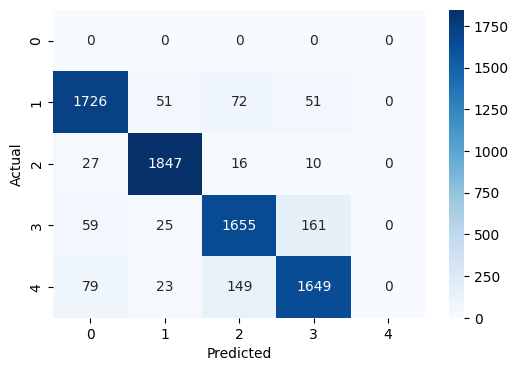

In [122]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)

#plotting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

**MODEL 2**

In [123]:
#classification report
y_pred = model2.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.03      0.03      0.03      1900
           2       0.02      0.02      0.02      1900
           3       0.08      0.08      0.08      1900
           4       0.00      0.00      0.00      1900

    accuracy                           0.03      7600
   macro avg       0.02      0.02      0.02      7600
weighted avg       0.03      0.03      0.03      7600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

[[   0    0    0    0    0]
 [1680   52  104   64    0]
 [  25 1826   33   16    0]
 [  52   16 1681  151    0]
 [  48   13  192 1647    0]]


Text(45.722222222222214, 0.5, 'Actual')

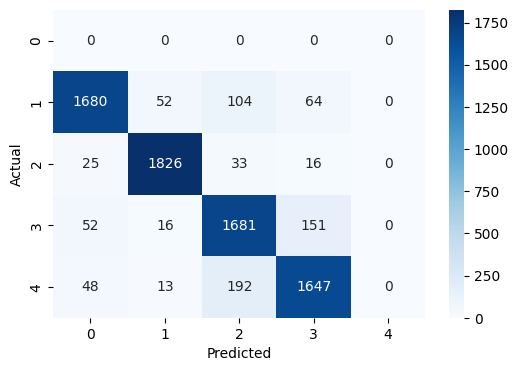

In [124]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)
#plotting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

Compare results

In [130]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
#model 1 (BiLSTM)
accuracy1 = accuracy_score(y_test, y_pred_classes1)
f1_1 = f1_score(y_test, y_pred_classes1, average='weighted')
recall1 = recall_score(y_test, y_pred_classes1, average='weighted')
precision1 = precision_score(y_test, y_pred_classes1, average='weighted')

#model 2 (BiGRU)
accuracy2 = accuracy_score(y_test, y_pred_classes2)
f1_2 = f1_score(y_test, y_pred_classes2, average='weighted')
recall2 = recall_score(y_test, y_pred_classes2, average='weighted')
precision2 = precision_score(y_test, y_pred_classes2, average='weighted')

#results
print("BiLSTM Model Metrics:")
print(f"  Accuracy: {accuracy1:.4f}")
print(f"  F1-score (weighted): {f1_1:.4f}")
print(f"  Recall (weighted): {recall1:.4f}")
print(f"  Precision (weighted): {precision1:.4f}")

print("\nBiGRU Model Metrics:")
print(f"  Accuracy: {accuracy2:.4f}")
print(f"  F1-score (weighted): {f1_2:.4f}")
print(f"  Recall (weighted): {recall2:.4f}")
print(f"  Precision (weighted): {precision2:.4f}")

#accuracy comparison
if accuracy1 > accuracy2:
    print("\nBiLSTM model performed better in terms of accuracy.")
elif accuracy2 > accuracy1:
    print("\nBiGRU model performed better in terms of accuracy.")
else:
    print("\nBoth models performed equally in terms of accuracy.")

#f-1
if f1_1 > f1_2:
    print("\nBiLSTM model performed better in terms of F1-score.")
else:
    print("\nBiGRU modelperformed better in terms of F1-score.")

#recall
if recall1 > recall2:
    print("\nBiLSTM model performed better in terms of recall.")
else:
    print("\nBiGRU modelperformed better in terms of recall.")

#precision
if precision1 > precision2:
    print("\nBiLSTM model performed better in terms of precision.")
else:
    print("\nBiGRU modelperformed better in terms of precision.")

BiLSTM Model Metrics:
  Accuracy: 0.0300
  F1-score (weighted): 0.0301
  Recall (weighted): 0.0300
  Precision (weighted): 0.0302

BiGRU Model Metrics:
  Accuracy: 0.0311
  F1-score (weighted): 0.0310
  Recall (weighted): 0.0311
  Precision (weighted): 0.0310

BiGRU model performed better in terms of accuracy.

BiGRU modelperformed better in terms of F1-score.

BiGRU modelperformed better in terms of recall.

BiGRU modelperformed better in terms of precision.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classifi

# Briefly discuss which model performed better and why might that be the case?

-BiGRU Model performed better slightly than BiLSTM in terms of accuracy.Because BiGRU is a less complex model architecture and less parameters.